### Build Recommendation system:
- Solution:
  - Popularity (no personalization)
  - Classification model (Features may be unavaliable) 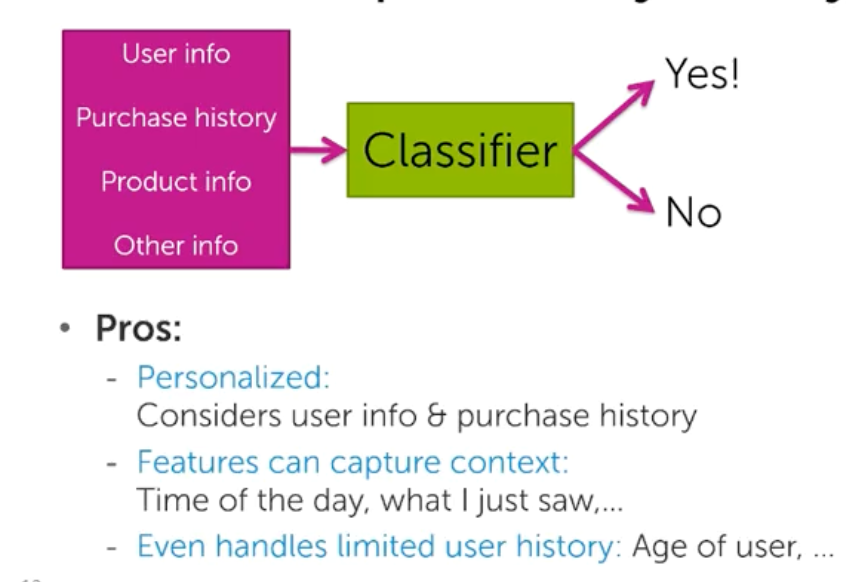
  - Co-occurrence Matrix (people who bought this, also bought...)
    - Co-occuuence must be normalized
  - Discovering hidden structure by matrix factorization (movie recommendation)

**Co-occurrence Matrix:**
- Normalize co-occurrences similarity matrix:
Limitations:

  1) Does **not** utilize context(eg: time of day), user features(eg: age), product features(eg: baby vs electronics)

  2) Cold start problem: what id a new user or product arrives?


**Jaccard similarity**
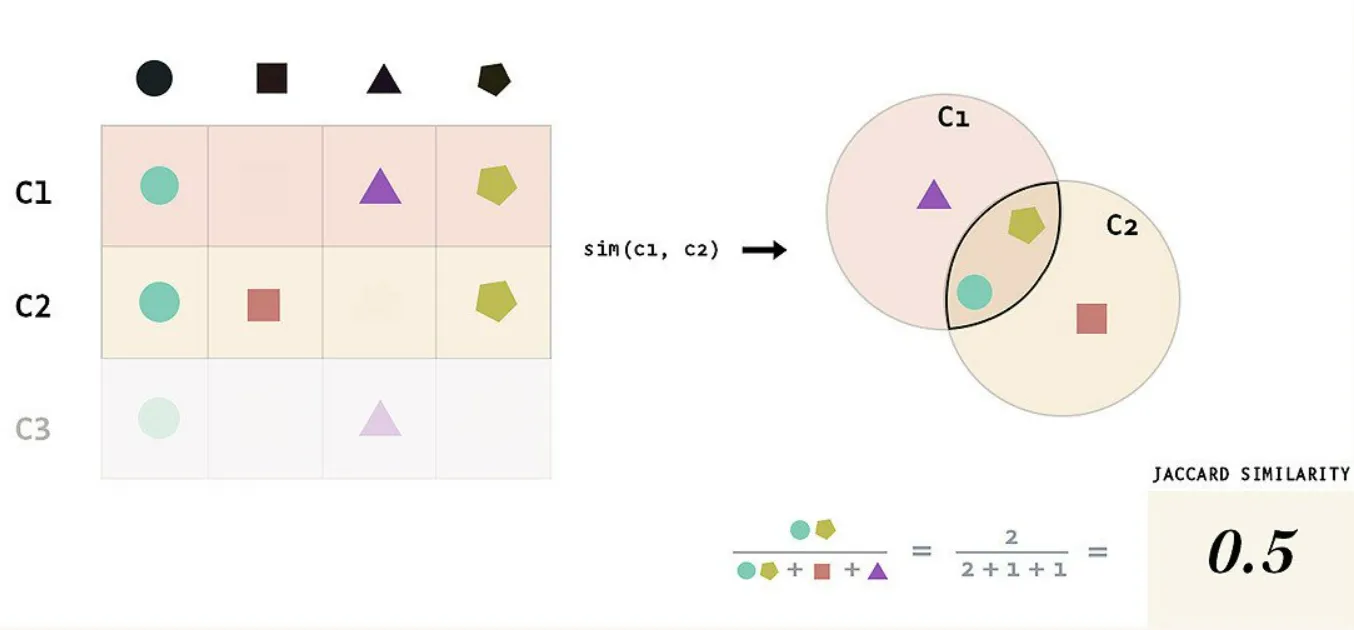 a measure of similarity between two asymmetric binary vectors or we can say a way to find the similarity between two sets. It is a common proximity measurement used to compute the similarity of two items, such as two text documents. The index ranges from 0 to 1. Range closer to 1 means more similarity in two sets of data.

- Jaccard Similarity = (number of observations in both sets) / (number in either set)

- Jaccard Distance = 1 — Jaccard Similarity

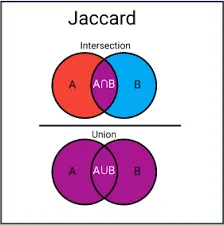

## Build a song recommender system


In [1]:
# import necessary libs

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sklearn


In [2]:
# Load dataset by pandas
import pandas as pd
df =pd.read_csv("song_data.csv")
df.head()

,user_id,song_id,listen_count,title,artist,song
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1,The Cove,Jack Johnson,The Cove - Jack Johnson
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2,Entre Dos Aguas,Paco De Lucia,Entre Dos Aguas - Paco De Lucia
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBXHDL12A81C204C0,1,Stronger,Kanye West,Stronger - Kanye West
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBYHAJ12A6701BF1D,1,Constellations,Jack Johnson,Constellations - Jack Johnson
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODACBL12A8C13C273,1,Learn To Fly,Foo Fighters,Learn To Fly - Foo Fighters


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1116609 entries, 0 to 1116608
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   user_id       1116609 non-null  object
 1   song_id       1116609 non-null  object
 2   listen_count  1116609 non-null  int64 
 3   title         1116609 non-null  object
 4   artist        1116609 non-null  object
 5   song          1116609 non-null  object
dtypes: int64(1), object(5)
memory usage: 51.1+ MB


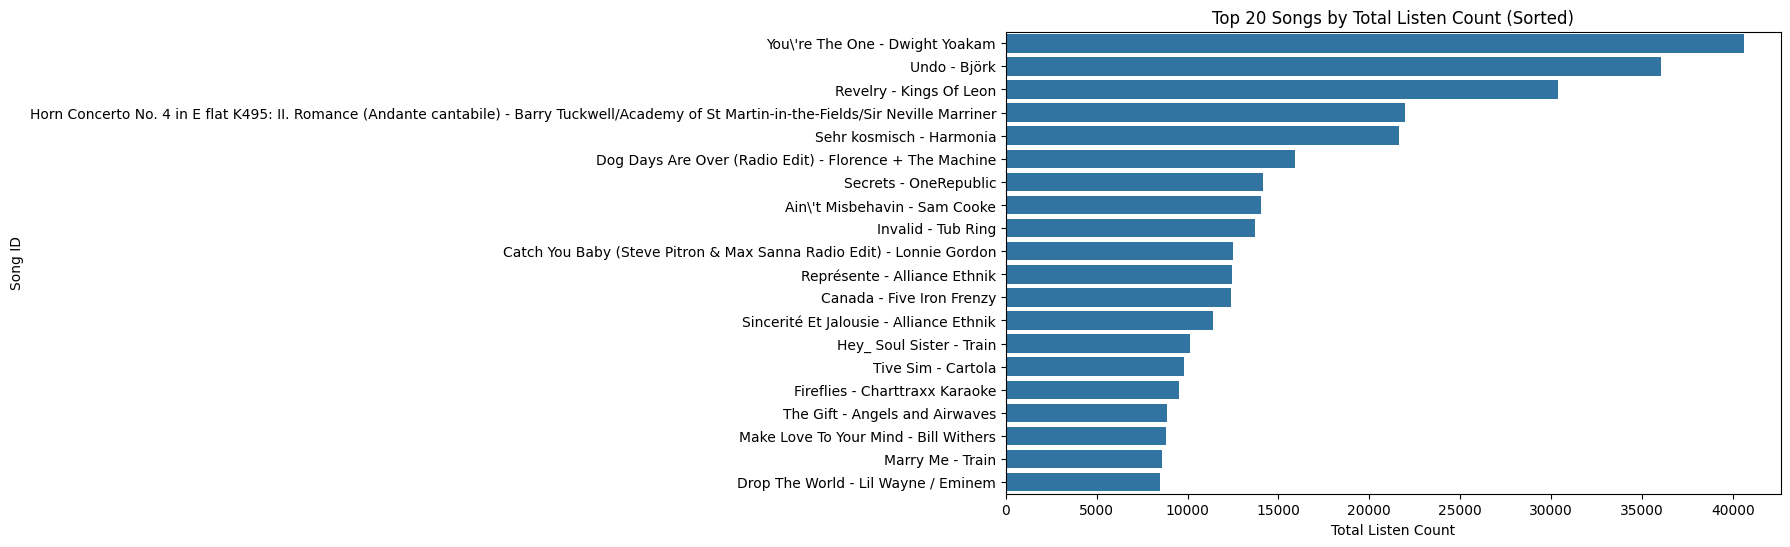

In [4]:
# Draw top 20 songs by total listen
song_listen_counts = df.groupby('song')['listen_count'].sum()
# Sort the song_listen_counts in descending order and take top 20
top_20_songs = song_listen_counts.sort_values(ascending=False).head(20)

# Create the horizontal bar plot with sorted data
plt.figure(figsize=(10, 6))  # Adjust figure height
sns.barplot(x=top_20_songs, y=top_20_songs.index, orient='h')
plt.xlabel('Total Listen Count')
plt.ylabel('Song ID')
plt.title('Top 20 Songs by Total Listen Count (Sorted)')
plt.show()

In [5]:
# Count the number of unique users
users = df['user_id'].unique()
len(users)

66346

In [6]:

df_grouped = df.groupby('artist').agg(total_count=('listen_count', 'sum')).reset_index()
df_grouped


,artist,total_count
0,!!!,157
1,+ / - {Plus/Minus},475
2,+44,313
3,10 Years,560
4,1001,68
...,...,...
3370,moe.,402
3371,rinôçérôse,104
3372,the bird and the bee,3161
3373,themselves,80


### Create a song recommender

In [7]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(df, test_size=0.2, random_state=0)

**Build a very simple popularity recommendern**

In [8]:
# Step 1: Count how many times each song appears (i.e., is played)
song_popularity = train_data['song'].value_counts().reset_index()
song_popularity.columns = ['song', 'score']

# Step 2: Create a function to recommend top N songs to any user
def recommend_popular_songs(user_id, top_n=10):
    # Simply return the top N most popular songs for any user
    recommendations = song_popularity.head(top_n).copy()
    recommendations['user_id'] = user_id
    return recommendations[['user_id', 'song', 'score']]

# Example usage:
recommend_popular_songs(user_id='user_000001', top_n=5)


,user_id,song,score
0,user_000001,Sehr kosmisch - Harmonia,4812
1,user_000001,Undo - Björk,4211
2,user_000001,You\'re The One - Dwight Yoakam,3819
3,user_000001,Dog Days Are Over (Radio Edit) - Florence + Th...,3624
4,user_000001,Revelry - Kings Of Leon,3485


In [9]:
#Use the above model to make some predictions

# Example usage with a different user ID and top_n value:
recommendations = recommend_popular_songs(user_id='user_000010', top_n=3)
print(recommendations)

# Example usage with a user ID not present in the dataset
recommendations = recommend_popular_songs(user_id='user_999', top_n=3)
recommendations


       user_id                             song  score
0  user_000010         Sehr kosmisch - Harmonia   4812
1  user_000010                     Undo - Björk   4211
2  user_000010  You\'re The One - Dwight Yoakam   3819


,user_id,song,score
0,user_999,Sehr kosmisch - Harmonia,4812
1,user_999,Undo - Björk,4211
2,user_999,You\'re The One - Dwight Yoakam,3819


**Build a recommender with personalization**

In [10]:
# prompt: Build a recommender with personalization

import pandas as pd
# Create a user-item interaction matrix
user_item_matrix = train_data.groupby(['user_id', 'song'])['listen_count'].sum().unstack().fillna(0)

# Function to calculate cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

def get_recommendations(user_id, top_n=10):
    if user_id not in user_item_matrix.index:
        return recommend_popular_songs(user_id, top_n)  # Fallback to popularity-based recommendations

    user_vector = user_item_matrix.loc[user_id].values.reshape(1, -1)
    similarity_scores = cosine_similarity(user_vector, user_item_matrix)
    similar_users = similarity_scores.argsort()[0][-2:-12:-1] # Get the indices of top 10 similar users excluding the user itself.

    # Aggregate song recommendations from similar users
    recommendations = []
    for user in user_item_matrix.index[similar_users]:
        recommendations.extend(list(user_item_matrix.loc[user][user_item_matrix.loc[user] > 0].index)) # Consider only songs with positive interaction

    recommendations = list(set(recommendations)) # remove duplicate recommendations
    
    # Filter out songs the user has already listened to
    listened_songs = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] > 0].index
    recommendations = [song for song in recommendations if song not in listened_songs]

    # Return the top N recommendations
    return pd.DataFrame({'user_id': [user_id]*min(len(recommendations), top_n), 'song': recommendations[:top_n]})

# Example usage
recommendations = get_recommendations('user_000001', top_n=5)
recommendations

,user_id,song,score
0,user_000001,Sehr kosmisch - Harmonia,4812
1,user_000001,Undo - Björk,4211
2,user_000001,You\'re The One - Dwight Yoakam,3819
3,user_000001,Dog Days Are Over (Radio Edit) - Florence + Th...,3624
4,user_000001,Revelry - Kings Of Leon,3485


In [11]:
subset_test_users = test_data['user_id'].unique()[0:10000]
subset_test_users

array(['8f8f909dd86e77969d1f8753e10ac56c4c68aa72',
       'd5a1b1b8142327cea378f262b96ef5675c8bff99',
       '58907ab6047361c85eb92be39dcbd2f0eb924684', ...,
       '3129bd6cd9c24b306b5b3f097e036ae63773caaa',
       '0752faf858265a1daf5da0e50e41bce6187d0a47',
       'e86496959f7404a1818d1eb526179a78329c3d95'], dtype=object)

In [12]:
# Which of the artists have had the most unique users listening to their songs?

unique_users_per_artist = df.groupby('artist')['user_id'].nunique().sort_values(ascending=True)
artist_with_most_unique_users = unique_users_per_artist.idxmax()
print(f"The artist with the most unique users is: {artist_with_most_unique_users}")
unique_users_per_artist

The artist with the most unique users is: Kings Of Leon


artist
William Tabbert             12
Elvis Perkins               20
harvey summers              22
Reel Feelings               22
Giannis Aggelakas           23
                          ... 
Florence + The Machine    5615
Björk                     5834
Harmonia                  5970
Coldplay                  6340
Kings Of Leon             7373
Name: user_id, Length: 3375, dtype: int64

In [13]:
artists = ['Kanye West', 'Foo Fighters', 'Taylor Swift', 'Lady GaGa']
for artist in artists:
  unique_users = df[df['artist'] == artist]['user_id'].nunique()
  print(f"Unique users for {artist}: {unique_users}")


Unique users for Kanye West: 2522
Unique users for Foo Fighters: 2055
Unique users for Taylor Swift: 3246
Unique users for Lady GaGa: 2928


In [14]:
# Which of the artists below is the most popular artist, the one with highest total listen_count, in the data set?

# Group the DataFrame by artist and sum the listen counts for each artist
artist_listen_counts = df.groupby('artist')['listen_count'].sum().sort_values(ascending=False)

# Find the artist with the highest total listen count
most_popular_artist = artist_listen_counts.idxmax()

print(f"The most popular artist is: {most_popular_artist}")
artist_listen_counts

The most popular artist is: Kings Of Leon


artist
Kings Of Leon                        43218
Dwight Yoakam                        40619
Björk                                38889
Coldplay                             35362
Florence + The Machine               33387
                                     ...  
Boggle Karaoke                          30
Diplo                                   30
Beyoncé feat. Bun B and Slim Thug       26
Reel Feelings                           24
William Tabbert                         14
Name: listen_count, Length: 3375, dtype: int64

In [15]:
# Which of the artists below is the least popular artist, the one with smallest total listen_count, in the data set?

# Find the artist with the lowest total listen count
least_popular_artist = artist_listen_counts.idxmin()

print(f"The least popular artist is: {least_popular_artist}")


The least popular artist is: William Tabbert
